In [60]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
import tensorflow as tf
from tensorflow import keras
np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


In [61]:
# real-data CSV produced by the data CSV-maker (no channel2, no tau_time)
CSV_PATH = Path("../csv/merged_ch2.csv")

# stage-1 artifacts (matched vs unmatched)
S1_DIR   = Path("models_stage1_unmatched_vs_matched")
S1_MODEL = S1_DIR / "stage1_unmatched_vs_matched_dnn_best.keras"
S1_PREP  = S1_DIR / "stage1_preprocess.joblib"     # bare sklearn Pipeline

# stage-2 artifacts (qqbar binary)
S2_DIR   = Path("models_stage2_qqbar_binary")
S2_MODEL = S2_DIR / "qqbar_binary_dnn_best.keras"
S2_PREP  = S2_DIR / "qqbar_binary_preprocessor.joblib"   # dict: imputer/scaler/features

OUTPUT_DIR = Path("outputs_data_measurement")
OUTPUT_DIR.mkdir(exist_ok=True)

STAGE1_THRESHOLD = 0.85    # keep jets whose matched-score exceeds this

for p in [CSV_PATH, S1_MODEL, S1_PREP, S2_MODEL, S2_PREP]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p.resolve()}")
print("All artifacts found. CSV:", CSV_PATH.resolve())

All artifacts found. CSV: /Users/alexmendonca/Desktop/pic2/csv/merged_ch2.csv


In [62]:
def engineer_stage2(df):
    """Exact stage-2 engineering (no deltaR34 transform). dpsi12 never becomes a feature."""
    df = df.copy()
    for col in ["pt_dispersion3", "pt_dispersion4"]:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))
    if "kt2" in df.columns:
        df["kt2"] = np.log1p(df["kt2"].clip(lower=0))
    df["z_sum"]=df["z1"]+df["z2"]; df["z_absdiff"]=np.abs(df["z1"]-df["z2"])
    df["z_min"]=np.minimum(df["z1"],df["z2"]); df["z_max"]=np.maximum(df["z1"],df["z2"])
    df["z_minmax_ratio"]=df["z_min"]/(df["z_max"]+1e-8)
    for c3,c4,name in [("N_charged3","N_charged4","N_charged"),("N_all3","N_all4","N_all"),
                       ("pt_weight3","pt_weight4","pt_weight"),
                       ("pt_dispersion3","pt_dispersion4","pt_dispersion")]:
        if c3 in df.columns and c4 in df.columns:
            v3,v4=df[c3],df[c4]; vmin,vmax=np.minimum(v3,v4),np.maximum(v3,v4)
            df[f"{name}_sum"]=v3+v4; df[f"{name}_absdiff"]=np.abs(v3-v4)
            df[f"{name}_min"]=vmin; df[f"{name}_max"]=vmax
            df[f"{name}_minmax_ratio"]=vmin/(vmax+1e-8)
    return df

In [63]:
df = pd.read_csv(CSV_PATH)
print("Raw shape:", df.shape)

if "dpsi12" not in df.columns:
    raise ValueError("Data CSV must contain 'dpsi12' for the measurement.")

# data has NO channel2 / truth columns; confirm and continue
for forbidden in ["channel2", "is_qqbar", "stage1_target"]:
    if forbidden in df.columns:
        print(f"note: '{forbidden}' present in data CSV; it will be ignored (no truth used).")

# drop rows with NaN dpsi12 (failed splittings that slipped through)
n0 = len(df)
df = df[np.isfinite(df["dpsi12"])].copy().reset_index(drop=True)
print(f"Rows with finite dpsi12: {len(df):,} / {n0:,}")

Raw shape: (45755, 17)
Rows with finite dpsi12: 45,755 / 45,755


In [64]:
prep1 = load(S1_PREP)

# exact features the pipeline was fit on (raw columns, order preserved)
try:
    s1_features = list(prep1.named_steps["imputer"].feature_names_in_)
except Exception:
    # fall back to the first fitted step if the imputer isn't named "imputer"
    s1_features = list(prep1.steps[0][1].feature_names_in_)
print("Stage-1 expects", len(s1_features), "features")

missing = [c for c in s1_features if c not in df.columns]
if missing:
    raise ValueError(f"Data CSV missing stage-1 feature columns: {missing}")

X1 = df[s1_features].replace([np.inf, -np.inf], np.nan)
X1_pp = prep1.transform(X1).astype("float32")

m1 = keras.models.load_model(S1_MODEL, compile=False)
pred1 = m1.predict(X1_pp, batch_size=4096, verbose=1)
matched_score = pred1[:, 1] if (pred1.ndim == 2 and pred1.shape[1] == 2) else pred1.ravel()
df["stage1_matched_score"] = matched_score

keep = matched_score > STAGE1_THRESHOLD
print(f"Stage-1: {int(keep.sum()):,} / {len(df):,} jets pass matched-score > {STAGE1_THRESHOLD}")
df_m = df[keep].copy().reset_index(drop=True)

Stage-1 expects 12 features
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Stage-1: 3,537 / 45,755 jets pass matched-score > 0.85


[]

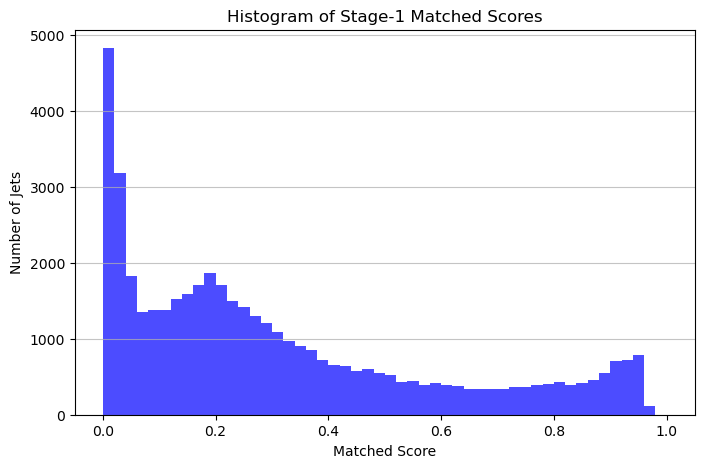

In [65]:
# Draw a histogram of the matched scores
plt.figure(figsize=(8, 5))
plt.hist(matched_score, bins=50, range=(0, 1), color='blue', alpha=0.7)
plt.title('Histogram of Stage-1 Matched Scores')
plt.xlabel('Matched Score')
plt.ylabel('Number of Jets')
plt.grid(axis='y', alpha=0.75)
plt.plot()

In [66]:
pp2 = load(S2_PREP)
imp2, scl2, feat2 = pp2["imputer"], pp2["scaler"], pp2["features"]

d2 = engineer_stage2(df_m)
missing = [c for c in feat2 if c not in d2.columns]
if missing:
    raise ValueError(f"Stage-2 missing feature columns: {missing}")
X2 = d2[feat2]
X2_pp = scl2.transform(imp2.transform(X2)).astype("float32")

m2 = keras.models.load_model(S2_MODEL, compile=False)
df_m["score"] = m2.predict(X2_pp, batch_size=4096, verbose=1).ravel()
print("Stage-2 score range:", round(float(df_m['score'].min()),3), "-", round(float(df_m['score'].max()),3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Stage-2 score range: 0.14 - 0.671


[]

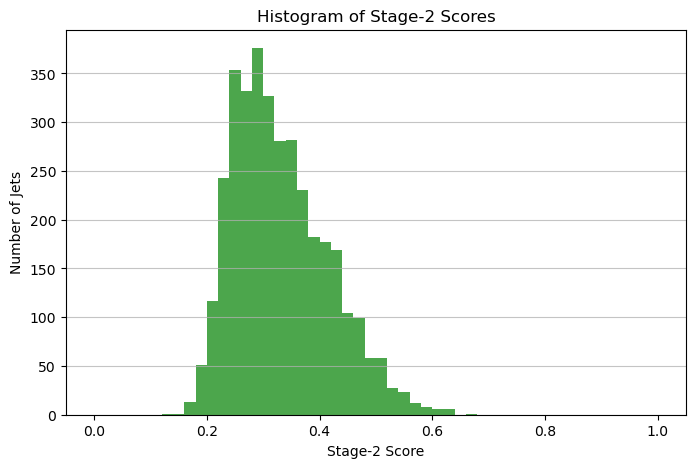

In [67]:
# Draw histogram of matched_score
plt.figure(figsize=(8, 5))
plt.hist(df_m['score'], bins=50, range=(0, 1), color='green', alpha=0.7)
plt.title('Histogram of Stage-2 Scores')
plt.xlabel('Stage-2 Score')
plt.ylabel('Number of Jets')
plt.grid(axis='y', alpha=0.75)
plt.plot()

In [68]:
dpsi  = df_m["dpsi12"].to_numpy()
score = df_m["score"].to_numpy()

# scan up to just below the max score so the last bin isn't empty
hi = min(0.95, float(score.max()))
lo = 0.0
thr_grid = np.linspace(lo, hi, 40)

rows = []
for thr in thr_grid:
    sel = score >= thr
    n = int(sel.sum())
    if n < 50:              # need enough jets for a meaningful mean
        print(f"Skipping threshold {thr:.3f} because only {n} jets pass.")
        continue
    cos2 = np.cos(2.0 * dpsi[sel])
    rows.append(dict(threshold=thr, N=n,
                     cos2_mean=cos2.mean(),
                     cos2_err=cos2.std()/np.sqrt(n)))
res = pd.DataFrame(rows)

# also the inclusive (no stage-2 cut) value on the stage-1-selected sample
cos2_incl = np.cos(2.0*dpsi)
print(f"Inclusive (stage-1 sample, no stage-2 cut): <cos2psi> = {cos2_incl.mean():+.4f} "
      f"+/- {cos2_incl.std()/np.sqrt(len(dpsi)):.4f}   N={len(dpsi):,}")
res.head(12)

Skipping threshold 0.550 because only 42 jets pass.
Skipping threshold 0.568 because only 27 jets pass.
Skipping threshold 0.585 because only 20 jets pass.
Skipping threshold 0.602 because only 13 jets pass.
Skipping threshold 0.619 because only 7 jets pass.
Skipping threshold 0.636 because only 2 jets pass.
Skipping threshold 0.654 because only 1 jets pass.
Skipping threshold 0.671 because only 1 jets pass.
Inclusive (stage-1 sample, no stage-2 cut): <cos2psi> = -0.1255 +/- 0.0119   N=3,537


,threshold,N,cos2_mean,cos2_err
0,0.000000,3537,-0.125502,0.011853
1,0.017200,3537,-0.125502,0.011853
2,0.034401,3537,-0.125502,0.011853
3,0.051601,3537,-0.125502,0.011853
4,0.068802,3537,-0.125502,0.011853
5,0.086002,3537,-0.125502,0.011853
6,0.103203,3537,-0.125502,0.011853
7,0.120403,3537,-0.125502,0.011853
8,0.137604,3537,-0.125502,0.011853
9,0.154804,3535,-0.125403,0.011858


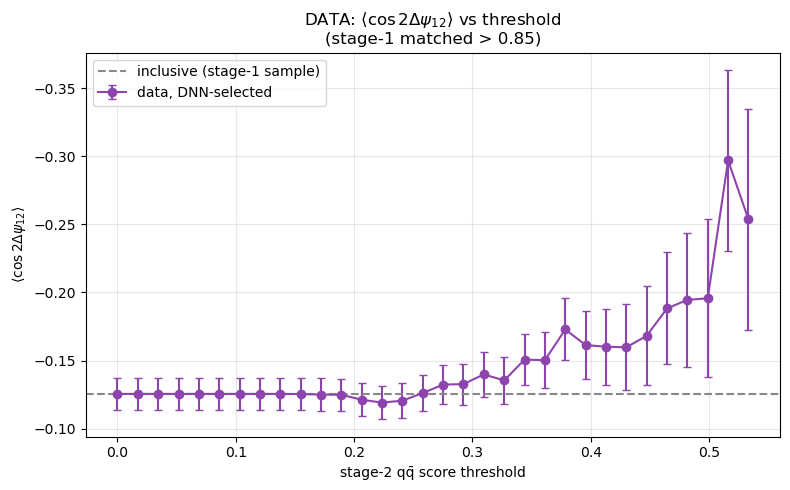

In [69]:
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(res["threshold"], res["cos2_mean"], yerr=res["cos2_err"],
            fmt="o-", color="#8e44ad", capsize=3, label="data, DNN-selected")
ax.axhline(cos2_incl.mean(), ls="--", color="#888888",
           label="inclusive (stage-1 sample)")
ax.set_xlabel("stage-2 qq̄ score threshold")
ax.set_ylabel(r"$\langle \cos 2\Delta\psi_{12}\rangle$")
ax.set_title(r"DATA: $\langle\cos 2\Delta\psi_{12}\rangle$ vs threshold"
             "\n(stage-1 matched > %.2f)" % STAGE1_THRESHOLD)
ax.grid(alpha=0.3); ax.legend(); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"data_cos2psi_vs_threshold.png", dpi=150); plt.show()

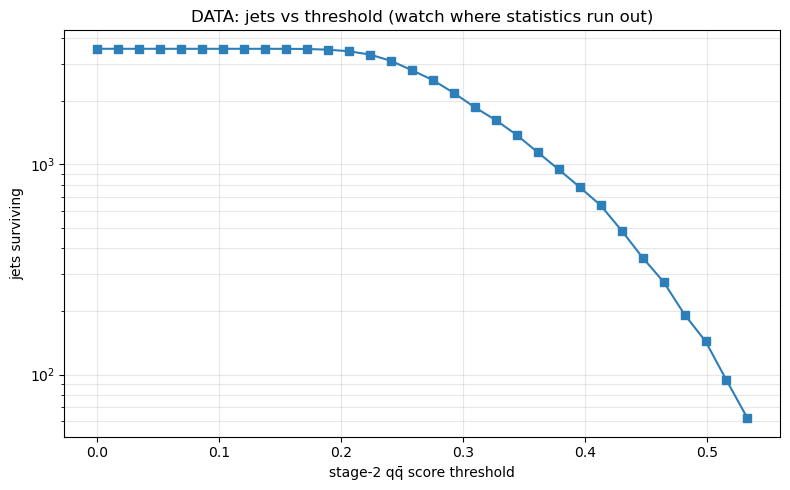

In [70]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(res["threshold"], res["N"], "s-", color="#2c7fb8")
ax.set_xlabel("stage-2 qq̄ score threshold")
ax.set_ylabel("jets surviving")
ax.set_yscale("log")
ax.set_title("DATA: jets vs threshold (watch where statistics run out)")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"data_N_vs_threshold.png", dpi=150); plt.show()